<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/ESAA_0529_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 평균 이동(Mean Shift)의 개요

평균 이동(Mean Shift)

: 중심을 군집의 중심으로 지속적으로 움직이면서 군집화 수행

: 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킴

<-> K-평균: 소속된 데이터의 평균 거리 중심으로 이동

: 데이터의 분포도를 이용해 군집 중심점을 찾음.

(군집 중심점: 데이터 포인트가 모여있는 곳. 가장 집중적으로 데이터가 모여있어 확률 밀도 함수가 피크인 점을 군집 중심점으로 선정.)

(KDE(Kernel Density Estimation)을 이용하여 확률 밀도 함수 찾음.)

: 특정 데이터를 반경 내의 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 위해 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동하는 방식

- 과정

개별 데이터의 특정 반경 내에 주변 데이터를 포함한 데이터 분포도를 KDE 기반 Mean Shift 알고리즘으로 계산 -> KDE로 계산된 데이터 분포도가 높은 방향으로 데이터 이동 -> 모든 데이터를 이동. 개별 데이터들이 군집중심점으로 모임. -> 지정된 반복 횟수만큼 전체 데이터에 대해 KDE 기반으로 데이터를 이동시키면서 군집화 수행 -> 개별 데이터들이 모인 중심점을 군집 중심점으로 설정

- KDE (Kernel Density Estimation)

: 커널함수를 통해 어떤 변수의 확률 밀도 함수를 추정하는 대표적인 방법

KDE=(1/n)*(시그마 i=1~i=n)(Kh(x-xi)=(1/nh)*(시그마 i=1~i=n)(K((x-xi)/h)

K: 커널 함수, x: 확률 변숫값, x: 관측값, h: 대역폭(bandwidth)

대역폭 h: KDE 형태를 부드러운(뾰족한) 형태로 평활화(smoothing) 하는데에 적용

: 적절한 kDE의 h를 계산하는 것이 KDE 기반의 평균 이동 군집화에서 매우 중요함.

(h를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능 좌우)

작은 h값(h=1,0): 좁고 뾰족한 KDE

(변동성이 큰 방식으로 확률 밀도 함수 추정 -> 과적합(over-fitting) 하기 쉬움.)

큰 h값(h=10): 과도하게 평활화(smoothing)된 KDE로 인해 지나치게 단순화된 방식으로 확률 밀도 함수 추정 -> 과소적합(under-fitting) 하기 쉬움.)


: MeanShift 클래스의 중요한 초기화 파라미터 bandwidth이 KDE의 대역폭 h와 동일

: 사이킷런은 초적의 대역폭 계산을 위해 estimate_bandwidth() 함수 제공

- make_bolbs()의 cluster_std를 0.7로 정한 3개 군집의 데이터에 대해 bandwidth를 0.8로 설정한 평균 이동 군집화 알고리즘 적용 예제

군집이 0부터 5까지 6개로 분류.

(bandwidth값을 작게 할수록 군집 개수가 많아짐.)

bandwidth를 1.0으로해서 MeanShift 수행

3개의 군집으로 군집화.

MeanShift에서는 이 bandwidth를 최적화 값으로 설정하는 것이 매우 중요.

-> estimate_bandwidth()의 파라미터로 피처 데이터 세트 입력 시 최적화된 bandwidth 값 반환

- estimate_bandwidth()로 측정된 badnwidth를 평균 이동 입력값으로 적용해 동일한 make_blobs() 데이터 세트에 군집화 수행

3개의 군집으로 구성

평균 이동도 중심을 가지고 있으므로 cluster_centers_ 속성으로 군집 중심 좌표 표시 가능

- target값, 군집 label 값 비교

Target값, 군집 label 값 1:1로 매칭됨.

- 평균 이동의 장점

: 유연한 군집화 가능

데이터 세트의 형태를 특정 형태로 가정 X, 특정 분포도 기반의 모델로 가정 X

- 평균 이동의 단점

: 알고리즘의 수행 시간 오래 걸림.

: band-width의 크기에 따른 군집화 영향도가 매우 큼.

- 평균 이동 군집화 기법

: 분석 업무 기반의 데이터 세트보다 컴퓨터 비전 영역에서 더 많이 사용됨.

: 이미지, 영상 데이터에서 특정 개체 구분, 움직임 추정하는 역할을 수행하는 알고리즘

# GMM(Gaussian Mixture Model)

GMM 군집화

: 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포(GaussianDistribution)를 가진 데이터 집합들이 섞여서 생성된 것이라는 가정하에 군집화를 수행하는 방식

: 모수 추정 방식

(추정 대상: 개별 정규 분포의 평균고 분산, 각 데이터가 어떤 정규 분포에 해당되는지의 확률)

(모수 추정을 위한 GMM의 EM(Expectation and Maximation) 방법 적용)

(EM 방식을 통한 모수 추정 군집화를 지원하기 위한 GaussianMixture) 클래스 지원)

가우시안 분포

: 좌우 대칭형의 종(Bell) 형태

GMM (Gaussian Mixture Model)

: 여러 개의 가우시안 분포가 섞인 것

# GMM을 이용한 붓꽃 데이터 세트 군집화

GMM: 확률 기반 군집화

K-평균: 거리 기반 군집화

- 붓꽃 데이터 세트로 GMM, K-평균 방식을 이용해 군집화 수행하여 양쪽 방식 비교

새로운 주피터 노트북 생성 -> 붓꽃 데이터 세트를 DataFrame으로 로드

GaussianMixture 객체의 가장 중요한 초기화 파라미터: n_components (gaussian mixture 모델의 총 개수)

n_components를 3으로 설정하여 GaussianMixture로 군집화 수행

GaussianMixture 객체의 fit(피처 데이터 세트)와 predict(피처 데이터 세트) 수행하여 군집 결정

irisDF DataFrame에 'gmm_cluster' 칼럼명으로 저장

(타깃별로 군집이 어떻게 매핑되었는지 확인)

Target 0은 cluster 0으로, Target 2는 cluster 1로 매핑

(Target 1만 cluster 2로 45개(90%),cluster 1로 5개(10%) 매핑)

붓꽃 데이터 세트의 K-평균 군집화 결과보다 더 효과적인 분류 결과 도출

(어떤 알고리즘에 더 뛰어나다는 의미 X, 붓꽃 데이터 세트가 GMM 군집화에 더 효과적)

<-> K-평균

평균 거리 중심으로 중심을 이둉하면서 군집화 수행 방식

(개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 매우 효과적으로 군집화 수행 가능)








In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y= make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)

meanshift=MeanShift(bandwidth=0.8)
cluster_labels=meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [2]:
meanshift=MeanShift(bandwidth=1)
cluster_labels=meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [3]:
from sklearn.cluster import estimate_bandwidth

bandwidth=estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth,3))

bandwidth 값: 1.816


In [4]:
import pandas as pd

clusterDF=pd.DataFrame(data=X, columns=['ftr1','ftr2'])
clusterDF['target']=y

# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth=estimate_bandwidth(X)

meanshift=MeanShift(bandwidth=best_bandwidth)
cluster_labels=meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


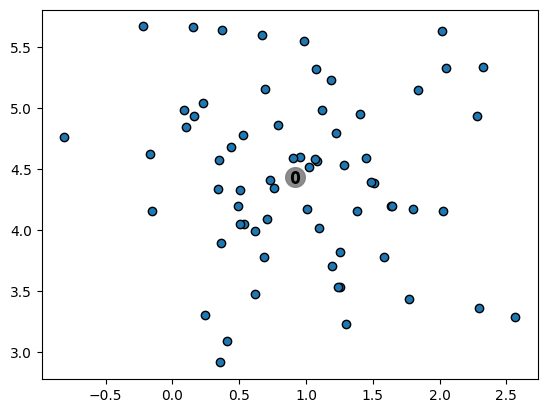

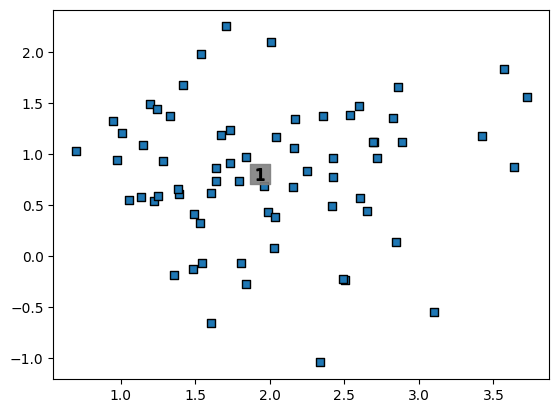

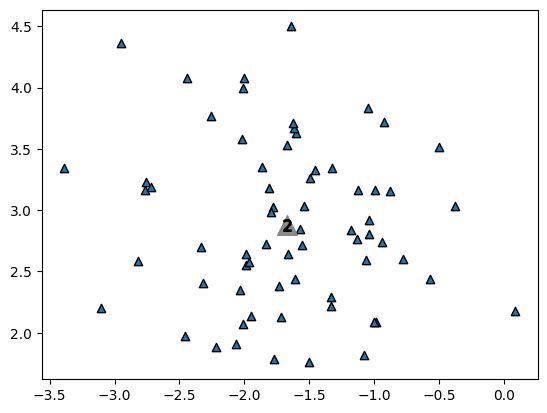

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label']=cluster_labels
centers=meanshift.cluster_centers_
unique_labels=np.unique(cluster_labels)
markers=['o','s','^','x','*']

for label in unique_labels:
  label_cluster=clusterDF[clusterDF['meanshift_label']==label]
  center_x_y=centers[label]

  # 군집별로 다른 마커로 산점도 적용
  plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

  # 군집별 중심 표현
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
              marker=markers[label])
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$'%label)

  plt.show()

In [9]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


In [10]:
from ast import increment_lineno
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris=load_iris()
feature_names=['sepal_length','sepal_width','petal_length', 'petal_width']

# 좀 더 편리한 데이터 HandLing을 위해 DataFrame으로 변환
irisDF=pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target']=iris.target

In [12]:
from sklearn.mixture import GaussianMixture

gmm=GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels=gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster']=gmm_cluster_labels
irisDF['target']=iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인.
iris_result=irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [14]:
kmeans=KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels=kmeans.predict(iris.data)
irisDF['kmeans_cluster']=kmeans_cluster_labels
iris_result=irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None,
                           label_name='target', iscenter=True):

    if dataframe is None:
        print("Error: DataFrame is required.")
        return

    unique_labels=np.unique(dataframe[label_name])
    markers=['o','s','^','x','*','D','+','v','<','>']

    for label in unique_labels:
        label_cluster=dataframe[dataframe[label_name]==label]

        plt.scatter(
            x=label_cluster['ftr1'],
            y=label_cluster['ftr2'],
            edgecolor='k',
            marker=markers[label % len(markers)]
        )

    plt.show()

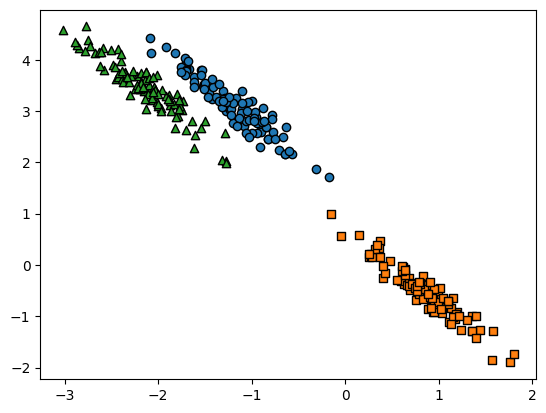

In [21]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std=0.5를 만듦.
X, y=make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함.
transformation=[[0.60834549,-0.63667341],[-0.40887718, 0.85253229]]
X_aniso=np.dot(X, transformation)
# feature 데이터 세트와 make_blobs()의 y 결괏값을 DataFrame으로 저장
clusterDF=pd.DataFrame(data=X_aniso, columns=['ftr1','ftr2'])
clusterDF['target']=y
# 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화함
visualize_cluster_plot(None, clusterDF,'target',iscenter=False)

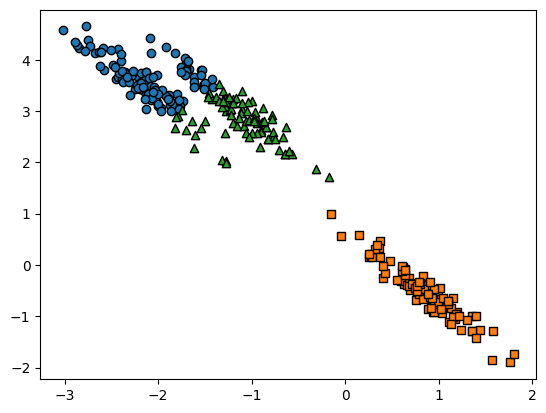

In [23]:
# 3개의 군집 기반 KMeans를 X_aniso 데이터 세트에 적용
kmeans=KMeans(3,random_state=0)
kmeans_label=kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label']=kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

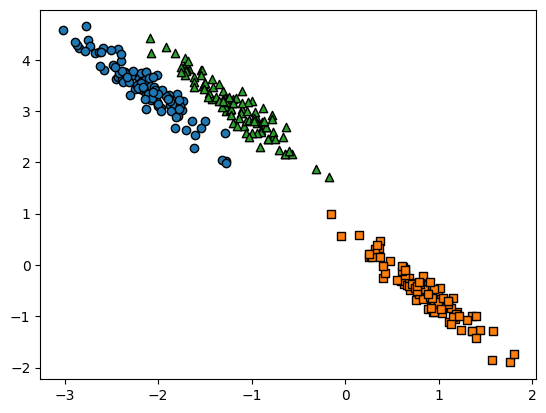

In [25]:
# 3개의 n_colponents 기반 GMM을 X_aniso 데이터 세트에 적용
gmm=GaussianMixture(n_components=3, random_state=0)
gmm_label=gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label']=gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정.
visualize_cluster_plot(gmm,clusterDF, 'gmm_label', iscenter=False)


In [26]:
print('## KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
print('\n## Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

## KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

## Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64
